In [347]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd

Dataset 1 Analysis

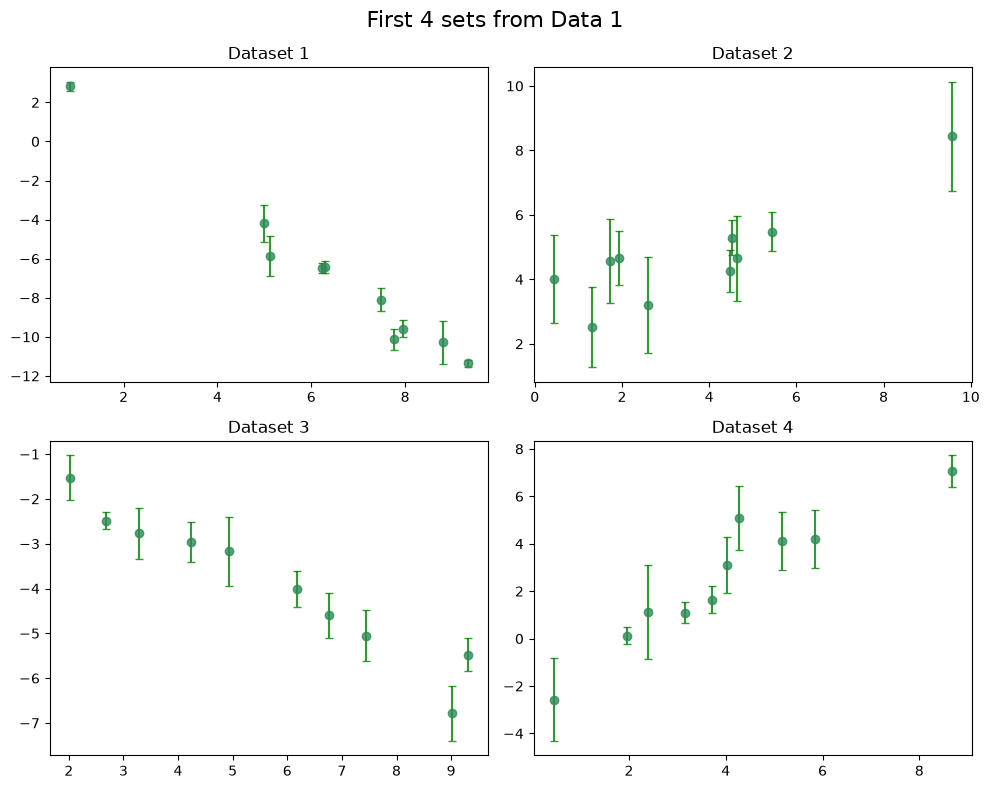

In [348]:
df = pd.read_csv('data1.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='seagreen',
                ecolor='green', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 1', fontsize=16)    
plt.tight_layout()
plt.show()


a = -1.6626831831611895, b = 3.817560809159585
a = 0.5117862550776586, b = 2.831272857074634
a ranges from -2.014 to 2.173
b ranges from -5.394 to 5.513


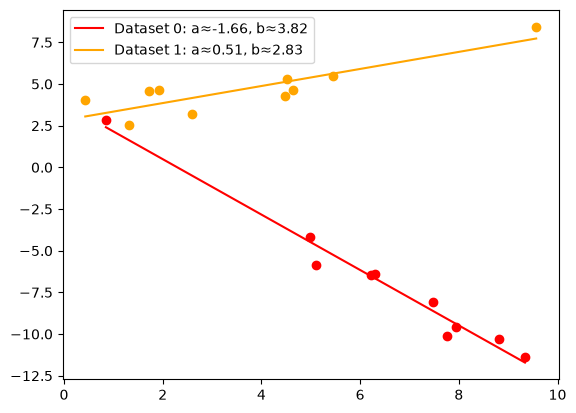

In [333]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

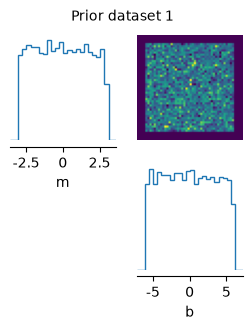

In [334]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_1 = BoxUniform(low=torch.tensor([-3, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples1 = prior_1.sample((10000,))


fig, ax = pairplot(
    prior_samples1,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 1", fontsize = 10 )
plt.show()

In [336]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, [sigma]])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].iloc[0]
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 145 epochs.

In [351]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
# for ds_id, d in list(datasets)[:]:
#     obs = get_observation(ds_id)
#     samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
#     posterior_mean = samples.mean(dim=0)
#     posterior_std = samples.std(dim=0)
    
#     results_list.append({
#         'dataset': ds_id,
#         'a_mean': posterior_mean[0].item(),
#         'a_std': posterior_std[0].item(),
#         'b_mean': posterior_mean[1].item(),
#         'b_std': posterior_std[1].item(),
#     })

# results_df = pd.DataFrame(results_list)
# print(results_df.to_string(index=False))

# #Corner for the first dataset only
# ds_id = 0
# obs = get_observation(ds_id)
# samples = posterior.sample((5000,), x=obs)

# flat_samples = samples.numpy()

# labels = ["m", "b"]
# fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

# posterior_mean = samples.mean(dim=0)



In [ ]:
#How good is this fitting?


Dataset 2 Analysis

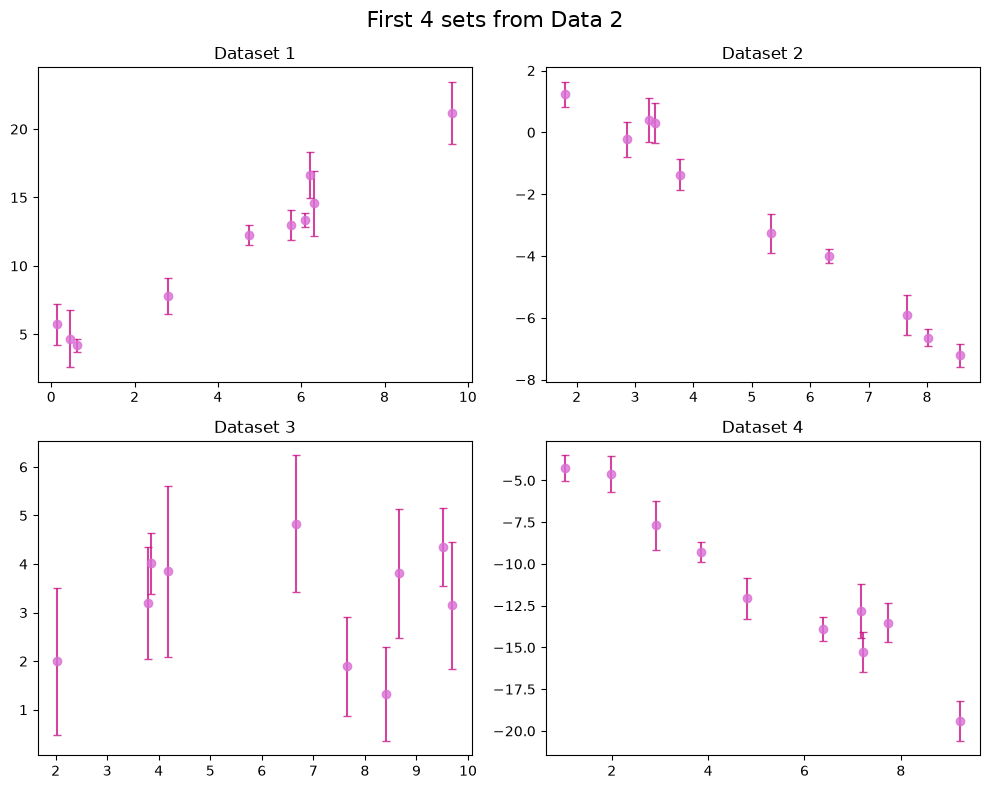

In [288]:
df = pd.read_csv('data2.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='orchid',
                ecolor='mediumvioletred', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 2', fontsize=16)    
plt.tight_layout()
plt.show()

a = 1.7458161902051454, b = 3.8832076996103444
a = -1.2948889985058631, b = 3.926804669969544
a ranges from -2.136 to 2.012
b ranges from -5.918 to 4.918


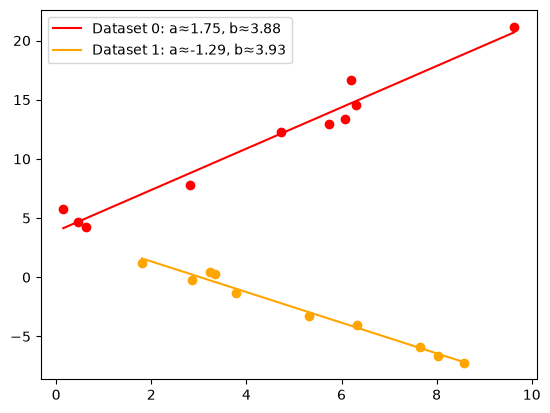

In [289]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

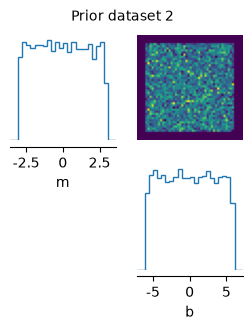

In [ ]:
#Creating a prior for the set based on that range

prior_2 = BoxUniform(low=torch.tensor([-3, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples2 = prior_2.sample((10000,))


fig, ax = pairplot(
    prior_samples2,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 2", fontsize = 10 )
plt.show()

In [270]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 200 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0  1.746337 0.125329  3.438063 0.519194
       1 -1.286772 0.063070  3.752219 0.382644
       2 -0.083552 0.131502  3.803927 0.894755
       3 -1.673998 0.127668 -2.587461 0.664824
       4 -0.910040 0.101513 -1.930591 0.676779
       5 -0.016325 0.155242  3.583704 0.589547
       6 -1.417259 0.202077 -2.781167 1.324917
       7 -0.797375 0.069875 -2.227201 0.406163
       8 -1.332942 0.129788  0.102584 0.681197
       9  1.995690 0.094463  0.866498 0.449937
      10  0.515790 0.084701 -4.046826 0.396096
      11  0.438949 0.049184  1.246994 0.375377
      12  1.242213 0.041663 -3.271538 0.222773
      13  1.851617 0.069608 -0.864905 0.389016
      14 -0.860982 0.097655  3.770765 0.431722
      15 -0.781061 0.198793 -3.111947 1.168954
      16 -0.152735 0.196702  3.404233 0.562982
      17 -0.471938 0.165157 -2.891758 0.604875
      18  1.293428 0.061973 -2.809562 0.438778
      19  1.798966 0.130652  1.355720 0.832225
      20  0.1

  0%|          | 0/5000 [00:00<?, ?it/s]

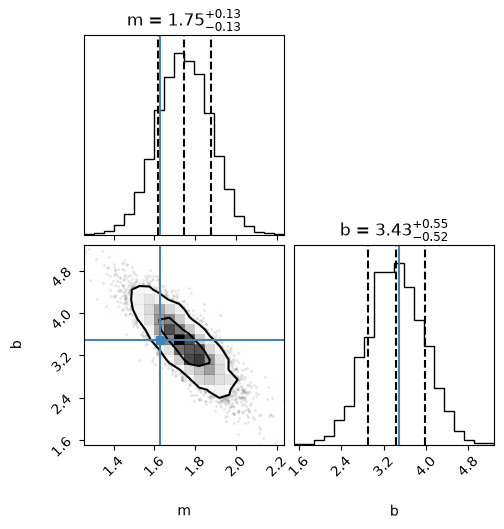

In [ ]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv
truths = [1.629722,3.493063]
labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



Dataset 3 Analysis

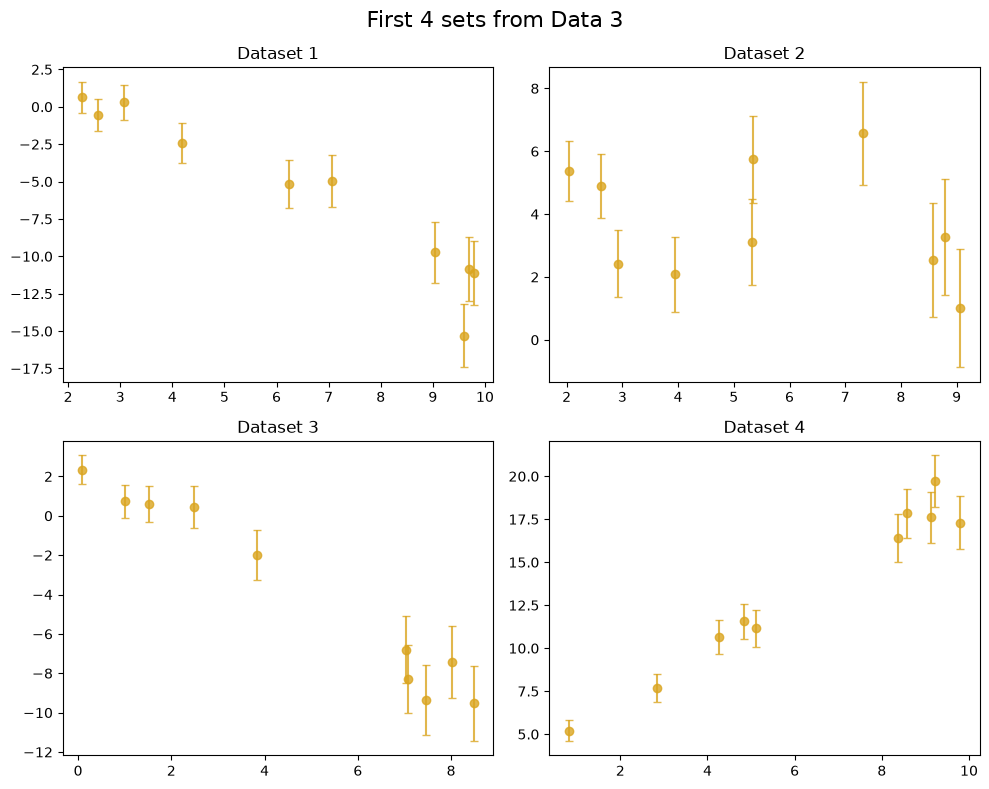

In [323]:
df = pd.read_csv('data3.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='goldenrod',
                ecolor='goldenrod', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 3', fontsize=16)    
plt.tight_layout()
plt.show()

a = -1.7072390028297482, b = 4.92599730988589
a = -0.1969695584637027, b = 4.806833987309417
a ranges from -1.977 to 2.213
b ranges from -5.324 to 5.409


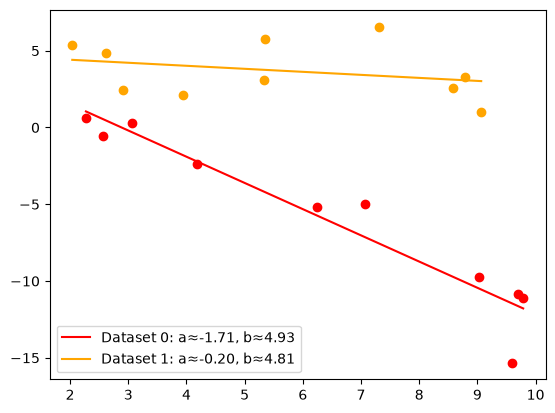

In [324]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')


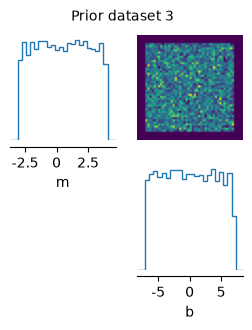

In [326]:
#Creating a prior for the set based on that range

prior_3 = BoxUniform(low=torch.tensor([-3, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples3 = prior_3.sample((10000,))

fig, ax = pairplot(
    prior_samples3,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 3", fontsize = 10 )
plt.show()

In [328]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 46 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.594355 0.184195  4.333565 0.985899
       1 -0.173058 0.194687  4.787125 0.907708
       2 -1.367313 0.142197  2.559002 0.525498
       3  1.575841 0.118607  3.629964 0.601320
       4 -0.103356 0.113760 -2.682059 0.441478
       5  1.430511 0.206773  3.561707 0.855456
       6 -1.199429 0.174173  3.204238 0.568461
       7  1.037828 0.106283 -3.048427 0.356509
       8 -0.154972 0.044838  4.031113 0.169322
       9  0.385664 0.038755 -4.378976 0.199090
      10  0.408289 0.147662 -3.997413 0.768708
      11 -1.574626 0.115040  2.856668 0.438420
      12  0.454940 0.139345  3.607556 0.648908
      13  0.493602 0.065185 -3.260504 0.333123
      14  0.136516 0.048068 -4.688656 0.197888
      15  0.312480 0.103637  0.521481 0.402969
      16  1.702444 0.150587  2.501652 0.762426
      17 -0.880305 0.115012 -3.358987 0.612113
      18 -1.081962 0.067074  0.101803 0.286280
      19  0.232266 0.099933  2.949223 0.462867
      20 -1.3

  0%|          | 0/5000 [00:00<?, ?it/s]

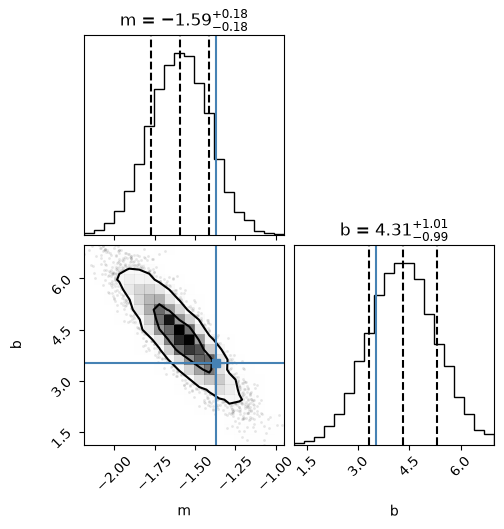

In [330]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv
truths = [-1.369837, 3.519913]
labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

Dataset 4 Analysis

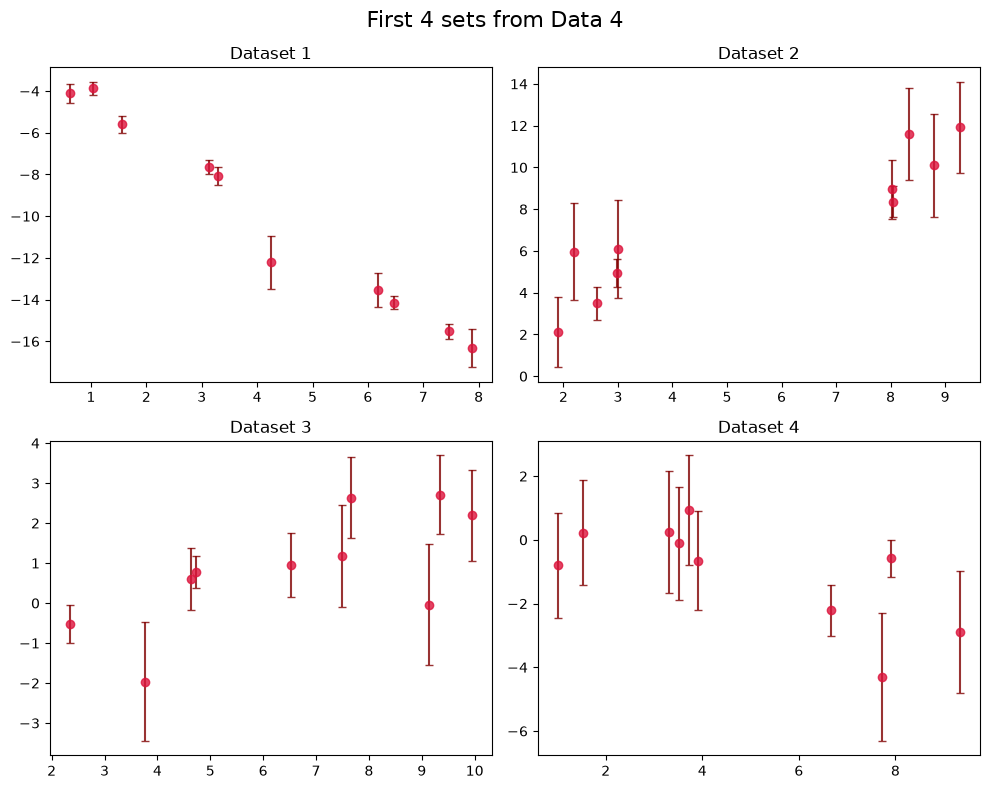

In [317]:
df = pd.read_csv('data4.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='crimson',
                ecolor='maroon', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 4', fontsize=16)    
plt.tight_layout()
plt.show()

a = 0.04653160904023226, b = -2.150237953415674, c = -2.2178123307472726
a = 0.03023175231962516, b = 0.6434463866665536, c = 2.6155669243001576
a ranges from -0.265 to 0.381
b ranges from -3.825 to 2.931
c ranges from -6.627 to 18.281


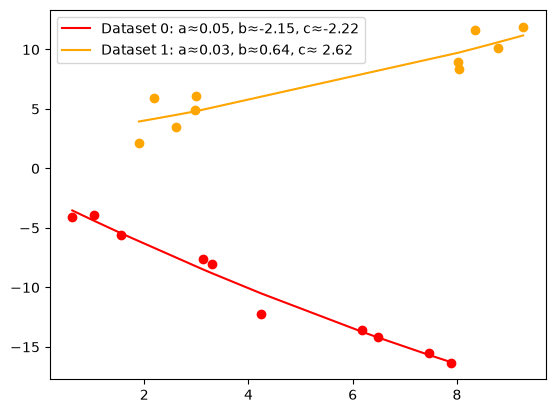

In [318]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []
c_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit, c_fit = np.polyfit(d['x'], d['y'], 2)

    a_fits.append(a_fit)
    b_fits.append(b_fit)
    c_fits.append(c_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit, c_fit = np.polyfit(d['x'], d['y'], 2)
    plt.plot(d['x'], a_fit * d['x']**2 + b_fit * d['x'] + c_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}, c≈{c_fit: .2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}, c = {c_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')
print(f'c ranges from {min(c_fits):.3f} to {max(c_fits):.3f}')

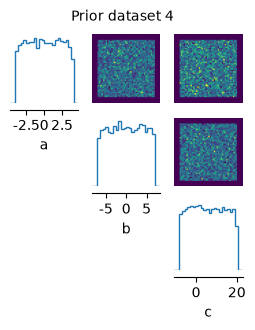

In [319]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_4 = BoxUniform(low=torch.tensor([-4, -7, -8]), 
                      high=torch.tensor([4, 7, 20]))

prior_samples4 = prior_4.sample((10000,))


fig, ax = pairplot(
    prior_samples4,
    labels=["a", "b", 'c'],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 4", fontsize = 10 )
plt.show()

In [320]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise

    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000  
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 120 epochs.

 dataset    a_mean    a_std    b_mean    b_std    c_mean    c_std
       0  0.026199 0.064775 -1.921820 0.493524 -2.649917 0.562779
       1  0.001898 0.136881  1.121866 1.586486  1.457539 3.462204
       2 -0.043563 0.056222  0.906163 0.662782 -2.887593 1.726384
       3 -0.069362 0.085603  0.359688 0.915652 -0.491589 1.964875
       4  0.029277 0.071838 -1.741920 0.630966  4.160232 0.811956
       5  0.055813 0.087132 -1.046390 1.117725 -0.189657 3.267092
       6 -0.010348 0.051232  0.833667 0.550447  2.775722 1.083951
       7  0.031547 0.129385  0.818156 1.259640  5.937918 2.486423
       8  0.040095 0.072538 -0.001422 0.826991  3.868419 2.051713
       9 -0.064537 0.047569  2.803268 0.453980 -3.912937 0.638853
      10  0.083089 0.121121 -0.390488 1.127174  5.652908 1.919134
      11  0.002090 0.048471  1.002227 0.436310  0.638406 0.651546
      12 -0.072109 0.045377  0.095890 0.479712 -4.959384 0.976499
      13  0.265621 0.073442 -1.553573 0.675790  3.731215 1.098086
      14 -

  0%|          | 0/5000 [00:00<?, ?it/s]

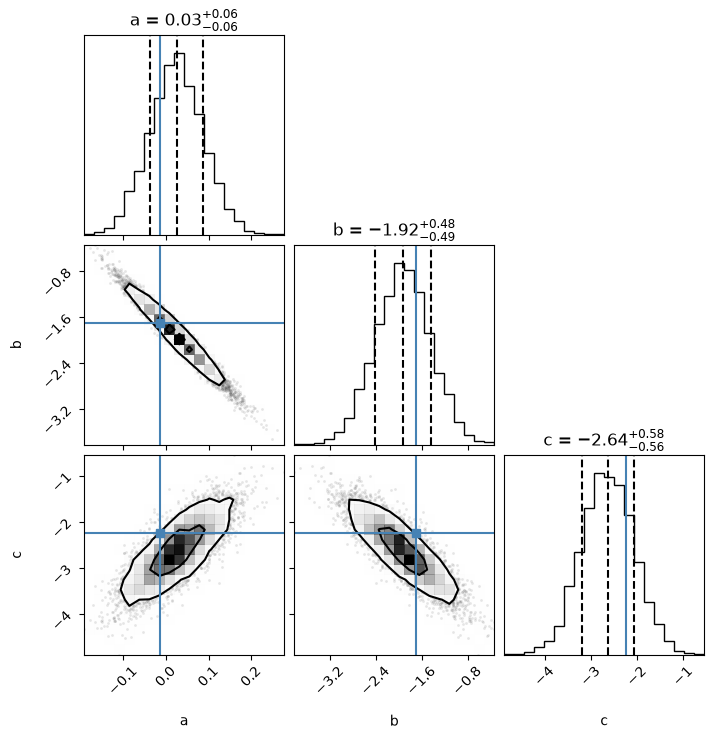

In [322]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item()
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv
truths = [-0.013794,-1.696825, -2.232021]
labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)